[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/storopoli/ciencia-de-dados/main?filepath=notebooks%2FAula_18_b__Redes_Neurais_com_PyTorch.ipynb)
<br>
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/storopoli/ciencia-de-dados/blob/main/notebooks/Aula_18_b_Redes_Neurais_com_PyTorch.ipynb)

# Redes Neurais com PyTorch

**Objetivos**: Aprender Redes Neurais Artificiais (RNA) usando a biblioteca `PyTorch`.

## PyTorch

[**PyTorch**](https://www.pytorch.org/) é uma biblioteca de código aberto para aprendizado de máquina aplicável a uma ampla variedade de tarefas. Foi criada pelo **Facebook** em 2016 é a principal biblioteca para criação e treinamento de redes neurais artificiais. A API toda é escrita em Python mas é executada em C++ na CPU ou em CUDA/ROCM na GPU.

No momento que eu escrevo esse tutorial (Abril de 2021), PyTorch está superando o TensorFlow (Google) em desempenho e adoção de uso. Isso acontece tanto na [academia](http://horace.io/pytorch-vs-tensorflow/) (mensurado pela adoção de artigos científicos nos principais encontros científicos de Aprendizagem Profunda e Aprendizagem de Máquina) quanto na [indústria](https://www.infoworld.com/article/3597904/why-enterprises-are-turning-from-tensorflow-to-pytorch.html) (mensurado pela adoção de grandes e renomadas empresas de tecnologia).

### Atualização (Junho 2022):

TensorFlow está morto, Vida Longa ao PyTorch: [Google lost the battle for machine learning to Meta, insiders say. Now it's betting the future of its own products on a new internal AI project.](https://www.businessinsider.com/facebook-pytorch-beat-google-tensorflow-jax-meta-ai-2022-6).

> Now, under the shadow of PyTorch, Google has been quietly building out a machine learning framework, called JAX (at one point an acronym for "Just After eXecution," but officially no longer stands for anything), that many see as the successor to TensorFlow.

Meus comentários: JAX é mais um backend de _autodiff_ do que uma biblioteca de redes neurais.
Ou seja tem um uso muito mais amplo que PyTorch.
Por exemplo, como um amostrador Monte Carlo de correntes ou cadeias Markov (_Markov Chain Monte Carlo_ - MCMC).

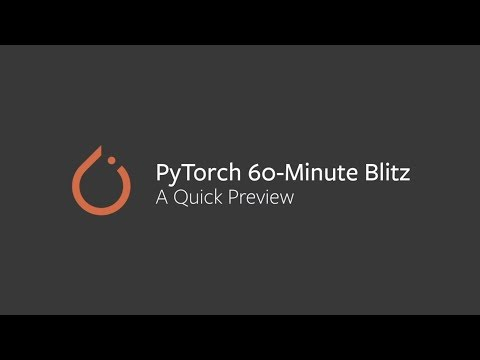

In [5]:
from IPython.display import YouTubeVideo

YouTubeVideo('u7x8RXwLKcA', width=600, height=400)

## O que é uma Rede Neural Artificial?

Redes neurais artificiais (RNAs) são modelos computacionais inspirados pelo sistema nervoso central (em particular o cérebro) que são capazes de realizar o aprendizado de máquina bem como o reconhecimento de padrões. Redes neurais artificiais geralmente são apresentadas como sistemas de "neurônios interconectados, que podem computar valores de entradas", simulando o comportamento de redes neurais biológicas.

<img src="https://github.com/storopoli/ciencia-de-dados/blob/main/notebooks/images/redes_neurais.jpeg?raw=1" alt="redes neurais" style="width: 500px;"/>

## Como a rede neural aprende?

Em cada neurônio há uma função de ativação (*activation function*) que processa uma combinação linear entre inputs e pesos sinápticos, gerando assim um sinal de saída.

A informação flui da *input layer* para as *hidden layers* e por fim para a *output layer*. Nesse fluxo os inputs de dados da *input layer* são alimentados para os neurônios das *hidden layers* que por fim alimentam o neurônio final da *output layer*.

A primeira passada de informação (propagação) pela rede é geralmente feita com parâmetros aleatórios para as funções de ativação dos neurônios.

Ao realizar a propagação, chamada de *feed forward*, temos sinais de saídas nos neurônios da output layer.

No fim da propagação, a função custo (uma métrica de erro) é calculada e o modelo então ajusta os parâmetros dos neurônios na direção de um menor custo (por meio do gradiente - derivada multivariada).

Assim uma nova propagação é gerada e a numa nova função custo e calculada. Assim como é realizado a atualização dos parâmetros dos neurônios.

O nome desse algoritmo é **Retro-propagação** (*Backpropagation*). E cada vez que ele é executado denomina-se como época (*epoch*). E quandos as épocas estabelecidas se encerram, a rede neural encerra o seu treinamento/aprendizagem.

<img src="https://github.com/storopoli/ciencia-de-dados/blob/main/notebooks/images/backpropagation.gif?raw=1" alt="backpropagation" style="width: 500px;"/>

## Funções de Ativação

| **Sigmoid**                                                  | **Tanh**                                                     | **ReLU**                                                     | **Leaky ReLU**                                               |
| ------------------------------------------------------------ | ------------------------------------------------------------ | ------------------------------------------------------------ | ------------------------------------------------------------ |
| $g(z)=\frac{1}{1+e^{-z}}$                                    | $g(z)=\frac{e^{z}-e^{-z}}{e^{z}+e^{-z}}$                     | $g(z)=\max (0, z)$                                           | $\begin{array}{c}{g(z)=\max (\epsilon z, z)} \\ {\text { com } \epsilon \ll 1}\end{array}$ |
| ![Illustration](https://github.com/storopoli/ciencia-de-dados/blob/main/notebooks/images/sigmoid.png?raw=1) | ![Illustration](https://github.com/storopoli/ciencia-de-dados/blob/main/notebooks/images/tanh.png?raw=1) | ![Illustration](https://github.com/storopoli/ciencia-de-dados/blob/main/notebooks/images/relu.png?raw=1) | ![Illustration](https://github.com/storopoli/ciencia-de-dados/blob/main/notebooks/images/leaky-relu.png?raw=1) |



### Estruturação dos módulos de PyTorch

```python
import torch
```
* [`torch.Tensor`](https://pytorch.org/docs/stable/tensors.html) - Tensores (arrays N-D)
* [`torch.nn`](https://pytorch.org/docs/stable/nn.html) - Redes Neurais (_**N**eural **N**etworks_)
* [`torch.optim`](https://pytorch.org/docs/stable/optim.html) - Otimização (_**Optim**ization_)
* [`torch.data`](https://pytorch.org/docs/stable/data.html) - *Datasets* e Ferramentas de Streaming de Dados
* [`torch.autograd`](https://pytorch.org/docs/stable/autograd.html) - Diferenciação Automática (_**Auto**matic Differentiation_)
* [`torch.vision`](https://pytorch.org/docs/stable/torchvision/index.html) - Ferramentas de Manipulação de Imagens e Visão Computacional
* [`torch.audio`](https://pytorch.org/audio/stable/index.html) - Ferramentas de Manipulação de Áudio
* [`torch.jit`](https://pytorch.org/docs/stable/jit.html) - Compilação _**j**ust-**i**n-**t**ime_ de modelos PyTorch em binários


### `torch.Tensor`

* `NumPy` - `np.ndarray`
* `pandas` - `pd.Series` e `pd.DataFrame`
* `PyTorch` - `torch.Tensor`

## Algoritmos de Otimização

PyTorch possui diversos:
* **SGD**: _**S**tochastic **G**radient **D**escent_
* **SGD com Momento**: SGD com Momento usando a derivada (ou gradiente) do ponto atual
* **SGD com Momento Nesterov**: SGD com Momento mas  usa a derivada (ou o gradiente) parcial do ponto seguinte (Nesterov, 1983)
* **RMSprop**: SGD com taxa de aprendizagem adaptativa  (Hinton, Srivastava & Swersky, 2012) - `RMSProp`
* **AdaGrad**: SGD com taxa de aprendizagem adaptativa (Duchi, Hazan, & Yoram, 2011) -  `AdaGrad`
* **Adam**: SGD com taxa de aprendizagem adaptativa e momento (Kingma, Diederick & Jimmy, 2014) - `ADAM`

Os mais importantes são o SGD e o Adam

### SGD - Stochastic Gradient Descent

[`torch.optim.sgd()`](https://pytorch.org/docs/stable/_modules/torch/optim/sgd.html):

* `lr` - Taxa de Aprendizagem $\eta > 0$
* `momentum=0.0` - hyperparâmetro $\geq 0$ que acelera o *gradient descent* na direção relevante e mitiga oscilações.
* `nesterov=False` - `bool` para se aplica *Nesterov Momentum* ou não. *Nesterov Momentum* usa posições intermediárias do gradiente no cálculo do *momentum*. Proposto por Yuri Nesterov em 1983.
    

### Momentum

<img src="https://github.com/storopoli/ciencia-de-dados/blob/main/notebooks/images/momentum.gif?raw=1" alt="momentum" style="width: 300px;"/>

### Adam

Adam é um método de SGD que usa uma estimativa adaptativa dos momentos de primeira ordem e momentos de segunda ordem. Proposto por Kingma & Ba (2014).

[`torch.optim.Adam()`](https://pytorch.org/docs/stable/_modules/torch/optim/adam.html):

* `lr=0.001` - Taxa de Aprendizagem $\eta > 0$
* `betas=(0.9, 0.999)` - Uma tupla de valores:
    1. `betas[0]` - decréscimo exponencial da estimativa dos momentos de primeira ordem
    2. `betas[1]` - decréscimo exponencial da estimativa dos momentos de segunda ordem

### Momentum

<img src="https://github.com/storopoli/ciencia-de-dados/blob/main/notebooks/images/comparacao_otimizadores.gif?raw=1" alt="comparacao_otimizadores" style="width: 500px;"/>

### Momentum

<img src="https://github.com/storopoli/ciencia-de-dados/blob/main/notebooks/images/opt1.gif?raw=1" alt="comparacao_otimizadores_2" style="width: 500px;"/>

### Momentum

<img src="https://github.com/storopoli/ciencia-de-dados/blob/main/notebooks/images/opt2.gif?raw=1" alt="comparacao_otimizadores_3" style="width: 500px;"/>

## Funções Custo

As funções custos se dividem em dois tipos:

1. Funções Custo de **Classificação**
2. Funções Custo de **Regressão**

### Funcões Custo de Classificação

Mais utilizadas


* *Binary Cross-entropy* (Entropia cruzada binária): [`torch.nn.BCELoss()`](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)
* *Categorical Cross-entropy - Negative Log-Likelihood Loss* (Entropia cruzada categórica): [`torch.nn.NLLLoss()`](https://pytorch.org/docs/stable/generated/torch.nn.NLLLoss.html)

### Funcões Custo de Regressão

Mais utilizadas
* MSE - *Mean Squared Error* (Erro quadrado médio): [`torch.nn.MSELoss()`](https://pytorch.org/docs/stable/generated/torch.nn.MSELoss.html)
* MAE - *Mean Absolute Error - $\| . \|_1$* (Erro absoluto médio): [`torch.nn.L1Loss()`](https://pytorch.org/docs/stable/generated/torch.nn.L1Loss.html#torch.nn.L1Loss)

## Como construir sua rede neural no PyTorch

Construir redes neurais com o **PyTorch** é tão fácil quanto com **Keras**.

Temos que criar uma Rede Neural a partir de uma classe [`nn.Module()`](https://pytorch.org/docs/stable/generated/torch.nn.Module.html?highlight=module#torch.nn.Module) e criar um construtor com o método `__init__()` e implementar todas as layers e propagações desejadas com o método `forward()`.

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [7]:
class Model(nn.Module):
    # Construtor
    def __init__(self):  # Chamado de dunder methods __init__
        super(Model, self).__init__()
        self.fc1 = nn.Linear(4, 4) # primeira hidden layer
        self.fc2 = nn.Linear(4, 1) # segunda hidden layer

    # Propagação (Feed Forward)
    def forward(self, x):
        x = F.relu(self.fc1(x)) # poderia colocar F.leaky_relu
        x = F.relu(self.fc2(x))
        return x


# Instancia o Model()
model = Model()

print(model)

Model(
  (fc1): Linear(in_features=4, out_features=4, bias=True)
  (fc2): Linear(in_features=4, out_features=1, bias=True)
)


### Exemplo de Classificação Binária

In [8]:
class ClassBin(nn.Module):
    # Construtor
    def __init__(self):
        super(ClassBin, self).__init__()
        self.fc1 = nn.Linear(20, 20) # primeira hidden layer
        self.fc2 = nn.Linear(20, 1) # segunda hidden layer
        self.sigmoid = nn.Sigmoid() # output layer com ativação Sigmoid

    # Propagação (Feed Forward)
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.sigmoid(x)
        return x

model = ClassBin()

print(model)

ClassBin(
  (fc1): Linear(in_features=20, out_features=20, bias=True)
  (fc2): Linear(in_features=20, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


### Exemplo de Regressão

In [9]:
class Reg(nn.Module):
    # Construtor
    def __init__(self):
        super(Reg, self).__init__()
        self.fc1 = nn.Linear(20, 20) # primeira hidden layer
        self.fc2 = nn.Linear(20, 1) # segunda hidden layer output 1 único neurônio

    # Propagação (Feed Forward)
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return x

model = Reg()

print(model)

Reg(
  (fc1): Linear(in_features=20, out_features=20, bias=True)
  (fc2): Linear(in_features=20, out_features=1, bias=True)
)


### Exemplo de Multiclassificação (não-binária - acima de duas classes)

In [10]:
class MultiClass(nn.Module):
    # Construtor
    def __init__(self):
        super(MultiClass, self).__init__()
        self.fc1 = nn.Linear(20, 20)  # primeira hidden layer
        self.fc2 = nn.Linear(20, 10)  # segunda hidden layer
        self.softmax = nn.Softmax(10) # output layer com ativação ativação softmax com 10 classes

    # Propagação (Feed Forward)
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.softmax(x)
        return x

model = MultiClass()

print(model)

MultiClass(
  (fc1): Linear(in_features=20, out_features=20, bias=True)
  (fc2): Linear(in_features=20, out_features=10, bias=True)
  (softmax): Softmax(dim=10)
)


## Como treinar sua rede neural no PyTorch

Uma vez especificado e instanciado o modelo, podemos manipulá-lo de maneira dinâmica. Não é preciso "compilar" que nem o TensorFlow/Keras. Escolhemos a função custo (`loss_fn`) como `nn.NLLLoss()` e também a taxa de aprendizagem $\eta$ em `1e-6` e a quantidade de épocas a serem treinadas (`epochs`):

```python
model = Sua_rede_neural()
loss_fn = nn.NLLLoss()
learning_rate = 1e-6
epochs = 100

# Instânciar o Otimizador SGD
optimizer = torch.optim.sgd(model.parameters(), lr=learning_rate)

for t in range(epochs):
    model.train() # Colocar o modelo em modo de treinamento (calcula os gradientes)
    
    # Propagação (Feed Forward)
    y_pred = model(X_train)
    
    # Calcular erro usando a função-custo
    loss = loss_fn(y_pred, y_train)
    print(t, loss.item())

    # Zera os gradientes antes da Retro-propagação (Backpropagation)
    model.zero_grad()

    # Retro-propagação (Backpropagation)
    loss.backward()

    # Atualização dos parâmetros
    optimizer.step()
```

## Como ajustar o treinamento sua rede neural no PyTorch

* Batch Size
* Dropout

### Batch Size

Tamanho do Batch de dados que passa por vez pela rede neural antes da atualização dos parâmetros pelo *backpropagation*. Tamanhos grandes resultam em instabilidade no treinamento. Geralmente usam-se potências de $2$ $(2,4,8,16,\dots, 2^n)$.

Em Abril de 2018, Yann LeCun, um dos principais pesquisadores sobre redes neurais e ganhador do "nobel" da computação (Prêmio Turing) [twittou](https://twitter.com/ylecun/status/989610208497360896) em resposta à Masters & Luschi (2018) que mostrava diversos contextos de *batch size*:

>"Friends don't let friends use mini-batches larger than 32"

Então 32 é um valor empiricamente verificado que dá estabilidade ao treinamento.

> Dominic Masters and Carlo Luschi. "Revisiting small batch training for deep neural networks." _arXiv preprint arXiv:1804.07612_ (2018).

Para controlar como que os dados são inseridos no modelo e, logo, o Batch Size é preciso implementar um [`torch.utils.data.DataLoader()`](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader):

```python
import torch
from torch.utils.data import TorchDataset, DataLoader

# Converter X e y para torch.Tensor
X = torch.Tensor(X)
y = torch.Tensor(y)

# Um Dataset de Tensores - Array [X, y]
dataset = TensorDataset(X, y)
loader = DataLoader(dataset, batch_size=32, shuffle=True)
```

Argumentos do `DataLoader()`:

* **`dataset`**: um `Dataset` PyTorch
    * tem [vários tipos](https://pytorch.org/docs/stable/data.html)
    * no nosso exemplo vou usar um simples [`TensorDataset`](https://pytorch.org/docs/stable/_modules/torch/utils/data/dataset.html#TensorDataset) que é um wrapper de `np.ndarray` e `pd.Series` para `torch.Tensor`)
* **batch_size**: `int` - tamanho do Batch Size, padrão é 1
* **shuffle**: `bool` - se vai embaralhar os dados antes de enviar em batches ao modelo, padrão é `False`. Recomendo usar `shuffle=True`

### Dropout

Uma medida de regularização na qual evita-se overfitting proposta por Hinton em 2012. *Dropout* é um algoritmo que especifica que a cada iteração de época do treino os neurônios possuem uma probabilidade de serem removidos (não utilizados) para a aprendizagem. Geralmente a probabilidade ideal fica em torno de 20% ($0.2$).

Coloca-se como se fosse uma camada após a camada que deseja aplicar o dropout:

```python
model = torch.nn.Sequential(
    nn.Linear(4, 4) ,  # hidden layer
    nn.Dropout(0.2)    # dropout layer
)
```

<img src="https://github.com/storopoli/ciencia-de-dados/blob/main/notebooks/images/dropout.gif?raw=1" alt="dropout" style="width: 500px;"/>

## Exemplo com o dataset Titanic

Contém 891 passageiros reais do Titanic que afundou em 15/04/1912 matando 1502 de 2224 passageiros e tripulação que estavam a bordo.

* `survived`: *dummy* `0` ou `1`
* `pclass`: Classe do Passageiro
    - `1`: Primeira Classe
    - `2`: Segunda Classe
    - `3`: Terceira Classe
* `sex`: Sexo `male` ou `female`
* `age`: Idade
* `sibsp`: Número de Irmãos (*Siblings*) e Esposas (*spouse*) a bordo
* `parch`: Número de pais/filhos a bordo
* `fare`: Valor pago pela passagem em libras
* `embarked`: Porto que embarcou
    - `C`: Cherbourg
    - `Q`: Queenstown
    - `S`: Southampton)
* `class`: Mesmo que `pclass` só que em texto
* `adult_male`: *dummy* para `age > 16` e `sex == 'male'`
* `deck`: Qual deck a cabine do passageiro se situava
* `alive`: Mesmo que survived só que com `yes` ou `no`
* `alone`: *dummy* para se viajava sozinho

>Obs: usar `random_state = 123`

<img src="https://github.com/storopoli/ciencia-de-dados/blob/main/notebooks/images/titanic.png?raw=1" alt="titanic" style="width: 500px;"/>

In [11]:
import numpy as np
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
titanic = sns.load_dataset('titanic')

feature_names = ['pclass', 'female', 'age', 'fare']
titanic['female'] = titanic['sex'].map({'male': 0, 'female': 1})
titanic.dropna(subset=feature_names, inplace=True)  #891 para 714

X = titanic[feature_names].to_numpy()
y = titanic['survived'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.25,
                                                    random_state=123)

In [12]:
print('Tamanho de X_train: ', X_train.shape)
print('Tamanho de X_test: ', X_test.shape)
print('Tamanho de y_train: ', y_train.shape)
print('Tamanho de y_test: ', y_test.shape)

Tamanho de X_train:  (535, 4)
Tamanho de X_test:  (179, 4)
Tamanho de y_train:  (535,)
Tamanho de y_test:  (179,)


In [13]:
class ClassBin(nn.Module):
    # Construtor
    def __init__(self):
        super(ClassBin, self).__init__()
        self.linear1 = nn.Linear(4, 4)    # primeira hidden layer
        self.dropout1 = nn.Dropout(0.2)   # dropout layer
        self.linear2 = nn.Linear(4, 4)    # segunda hidden layer
        self.dropout2 = nn.Dropout(0.2)   # dropout layer
        self.linear3 = nn.Linear(4, 1)    # terceira hidden layer
        self.dropout3 = nn.Dropout(0.2)   # dropout layer
        self.sigmoid = nn.Sigmoid()

    # Propagação (Feed Forward)
    def forward(self, x):
        x = F.relu(self.linear1(x))
        x = self.dropout1(x)
        x = F.relu(self.linear2(x))
        x = self.dropout2(x)
        x = F.relu(self.linear3(x))
        x = self.dropout3(x)
        x = self.sigmoid(x)
        return x

model = ClassBin()
print(model)

ClassBin(
  (linear1): Linear(in_features=4, out_features=4, bias=True)
  (dropout1): Dropout(p=0.2, inplace=False)
  (linear2): Linear(in_features=4, out_features=4, bias=True)
  (dropout2): Dropout(p=0.2, inplace=False)
  (linear3): Linear(in_features=4, out_features=1, bias=True)
  (dropout3): Dropout(p=0.2, inplace=False)
  (sigmoid): Sigmoid()
)


In [14]:
loss_fn = nn.BCELoss()
epochs = 100
batch_size = 32  # X_train 535 / 32 = 16.71 (então são 17 batches de 32)
learning_rate = 0.1

# Instânciar o Otimizador Adam
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [15]:
from torch.utils.data import TensorDataset, DataLoader

# Converter X e y para torch.Tensor
X_train = torch.Tensor(X_train)
y_train = torch.Tensor(y_train)
X_test = torch.Tensor(X_test)
y_test = torch.Tensor(y_test)

# Um Dataset de Tensores - Array [X, y]
train = TensorDataset(X_train, y_train)
train_loader = DataLoader(train, batch_size=batch_size, shuffle=True)

test = TensorDataset(X_test, y_test)
test_loader = DataLoader(test, batch_size=batch_size, shuffle=True)

In [16]:
for t in range(epochs):
    model.train() # Colocar o modelo em modo de treinamento (calcula os gradientes)

    # Batch Size
    for data in train_loader:
        # dar nome aos bois
        X = data[0]
        y = data[1]

        # Propagação (Feed Forward)
        y_pred = model(X)

        # Calcular erro usando a função-custo
        # y precisa virar um Tensor com tamanho (batch_size, 1)
        loss = loss_fn(y_pred, y.unsqueeze_(1))

        # Zera os gradientes antes da Retro-propagação (Backpropagation)
        model.zero_grad()

        # Retro-propagação (Backpropagation)
        loss.backward()

        # Atualização dos parâmetros
        optimizer.step()

    # Fim da Época
    print(f"""Época {t + 1},
          Custo Treino: {round(loss.item(), 3)}""")

Época 1,
          Custo Treino: 0.693
Época 2,
          Custo Treino: 0.693
Época 3,
          Custo Treino: 0.693
Época 4,
          Custo Treino: 0.693
Época 5,
          Custo Treino: 0.693
Época 6,
          Custo Treino: 0.693
Época 7,
          Custo Treino: 0.693
Época 8,
          Custo Treino: 0.693
Época 9,
          Custo Treino: 0.693
Época 10,
          Custo Treino: 0.693
Época 11,
          Custo Treino: 0.693
Época 12,
          Custo Treino: 0.693
Época 13,
          Custo Treino: 0.693
Época 14,
          Custo Treino: 0.693
Época 15,
          Custo Treino: 0.693
Época 16,
          Custo Treino: 0.693
Época 17,
          Custo Treino: 0.693
Época 18,
          Custo Treino: 0.693
Época 19,
          Custo Treino: 0.693
Época 20,
          Custo Treino: 0.693
Época 21,
          Custo Treino: 0.693
Época 22,
          Custo Treino: 0.693
Época 23,
          Custo Treino: 0.693
Época 24,
          Custo Treino: 0.693
Época 25,
          Custo Treino: 0.693
Época 26,

### Acurácia do Modelo

Usar o comando `model.eval()`

Para a métrica acurácia, retorna um score de acurácia `float` entre $0$ e $1$
    
> Obs: Regressão Logística acurácias: 0.69 Treino e 0.7 Teste

> Obs: *Support Vector Machines* acurácias: 0.79 Treino e 0.75 Teste

> Obs: Árvores de Decisão acurácias: 0.79 Treino e 0.79 Teste

> Obs: Florestas Aleatórias acurácias: 0.84 Treino e 0.82 Teste

In [17]:
model.eval() # coloca o modelo em modo de avaliação (sem calcular gradientes)

train_pred = model(X_train)
train_pred = train_pred.detach().apply_(lambda x : 1 if x > 0.5 else 0)
train_acc = torch.sum(train_pred.flatten() == y_train) / train_pred.size(0)

test_pred = model(X_test)
test_pred = test_pred.detach().apply_(lambda x : 1 if x > 0.5 else 0)
test_acc = torch.sum(test_pred.flatten() == y_test) / test_pred.size(0)

print(f"Acurácia de Treino: {train_acc}")
print('\n ---------------------------\n')
print(f"Acurácia de Teste: {test_acc}")

Acurácia de Treino: 0.590654194355011

 ---------------------------

Acurácia de Teste: 0.6033519506454468


## Referências

* Hinton, Geoffrey, Nitish Srivastava, and Kevin Swersky. “Neural Networks for Machine Learning Lecture 6a Overview of Mini--Batch Gradient Descent,” 2012.
* Kingma, Diederik P., and Jimmy Ba. “Adam: A Method for Stochastic Optimization,” December 22, 2014. https://arxiv.org/abs/1412.6980.
* Nesterov, Y. A method of solving a convex programming problem with convergence rate O(1/sqr(k)). Soviet Mathematics Doklady, 27:372–376, 1983.
* Srivastava, Nitish, Geoffrey Hinton, Alex Krizhevsky, Ilya Sutskever, and Ruslan Salakhutdinov. “Dropout: A Simple Way to Prevent Neural Networks from Overfitting.” Journal of Machine Learning Research 15, no. 56 (2014): 1929–58.

---
# EXERCÍCIOS PROPOSTOS

## Exercício 1 — Função de Ativação ReLU

**Pergunta:** O que é uma função de ativação, como a ReLU? Por que normalmente usamos funções de ativação entre as camadas?

**Resposta:**

Uma **função de ativação** é uma transformação matemática aplicada à saída de cada neurônio antes de ela ser repassada para a próxima camada. Ela decide se e quanto aquele neurônio deve "disparar" com base em seu sinal de entrada.

A **ReLU** (*Rectified Linear Unit*) é definida como:

> `ReLU(z) = max(0, z)`

Ou seja, ela retorna o próprio valor caso seja positivo, e zero caso contrário.

Sem funções de ativação, empilhar várias camadas lineares resulta em uma única transformação linear — não importa quantas camadas existam, o modelo não seria mais expressivo que uma regressão linear simples. As funções de ativação introduzem **não-linearidade**, permitindo que a rede aprenda relações complexas nos dados.

A ReLU é preferida nas camadas ocultas porque:
- É computacionalmente simples e rápida de calcular;
- Mitiga o problema do \textit{vanishing gradient} presente na Sigmoid e Tanh;
- Mantém gradientes grandes para valores positivos, facilitando o aprendizado em redes profundas.

## Exercício 2 — `model.train()` e `optimizer.step()`

**Pergunta:** O que fazem as linhas `model.train()` e `optimizer.step()`? Qual a diferença entre `model.train()` e `model.eval()`?

**Resposta:**

### `model.train()`
Coloca o modelo em **modo de treinamento**. Isso ativa comportamentos que só devem ocorrer durante o treino, especificamente:
- **Dropout**: os neurônios são aleatoriamente zerados com a probabilidade definida, servindo como regularização.
- **BatchNorm**: usa as estatísticas do batch atual (média e variância do mini-batch).

Sem essa chamada, o Dropout não seria aplicado e o treinamento não funcionaria corretamente como regularizador.

### `optimizer.step()`
Executa um passo de atualização dos parâmetros da rede. Após o cálculo dos gradientes via `loss.backward()`, o otimizador lê os gradientes acumulados em cada parâmetro e aplica a regra de atualização (ex: Adam, SGD) para ajustar os pesos na direção que minimiza a função de perda.

### Diferença fundamental: `model.train()` vs `model.eval()`

| | `model.train()` | `model.eval()` |
|---|---|---|
| **Dropout** | Ativo (neurônios zerados aleatoriamente) | Desativado (todos neurônios usados) |
| **BatchNorm** | Usa estatísticas do batch | Usa estatísticas acumuladas |
| **Gradientes** | Calculados normalmente | Podem ser desativados com `torch.no_grad()` |
| **Uso** | Durante o treinamento | Durante avaliação / inferência |

Em resumo: `model.train()` é para aprender; `model.eval()` é para avaliar de forma determinística e eficiente.

## Exercício 3 — Nova Arquitetura sem Dropout

**Tarefa:** Modificar a classe `ClassBin` com arquitetura 4→16→8→1 sem Dropout, treinar e comparar acurácias.

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

# ── Preparação dos dados ──────────────────────────────────────────────────────
titanic = sns.load_dataset('titanic')
feature_names = ['pclass', 'female', 'age', 'fare']
titanic['female'] = titanic['sex'].map({'male': 0, 'female': 1})
titanic.dropna(subset=feature_names, inplace=True)

X = titanic[feature_names].to_numpy()
y = titanic['survived'].to_numpy()

X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X, y, test_size=0.25, random_state=123
)

X_train_t = torch.Tensor(X_train_np)
y_train_t = torch.Tensor(y_train_np)
X_test_t  = torch.Tensor(X_test_np)
y_test_t  = torch.Tensor(y_test_np)

In [19]:
# ── Modelo ORIGINAL (com Dropout, 4→4→4→1) ───────────────────────────────────
class ClassBinOriginal(nn.Module):
    def __init__(self):
        super(ClassBinOriginal, self).__init__()
        self.linear1  = nn.Linear(4, 4)
        self.dropout1 = nn.Dropout(0.2)
        self.linear2  = nn.Linear(4, 4)
        self.dropout2 = nn.Dropout(0.2)
        self.linear3  = nn.Linear(4, 1)
        self.dropout3 = nn.Dropout(0.2)
        self.sigmoid  = nn.Sigmoid()

    def forward(self, x):
        x = F.relu(self.linear1(x)); x = self.dropout1(x)
        x = F.relu(self.linear2(x)); x = self.dropout2(x)
        x = F.relu(self.linear3(x)); x = self.dropout3(x)
        x = self.sigmoid(x)
        return x

# ── Modelo NOVO (sem Dropout, 4→16→8→1) ──────────────────────────────────────
class ClassBinNovo(nn.Module):
    def __init__(self):
        super(ClassBinNovo, self).__init__()
        self.linear1 = nn.Linear(4, 16)   # entrada → 16 neurônios
        self.linear2 = nn.Linear(16, 8)   # 16 → 8 neurônios
        self.linear3 = nn.Linear(8, 1)    # 8 → saída
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = F.relu(self.linear1(x))
        x = F.relu(self.linear2(x))
        x = self.sigmoid(self.linear3(x))
        return x

print("Modelo Original:"); print(ClassBinOriginal())
print("\nModelo Novo:");    print(ClassBinNovo())

Modelo Original:
ClassBinOriginal(
  (linear1): Linear(in_features=4, out_features=4, bias=True)
  (dropout1): Dropout(p=0.2, inplace=False)
  (linear2): Linear(in_features=4, out_features=4, bias=True)
  (dropout2): Dropout(p=0.2, inplace=False)
  (linear3): Linear(in_features=4, out_features=1, bias=True)
  (dropout3): Dropout(p=0.2, inplace=False)
  (sigmoid): Sigmoid()
)

Modelo Novo:
ClassBinNovo(
  (linear1): Linear(in_features=4, out_features=16, bias=True)
  (linear2): Linear(in_features=16, out_features=8, bias=True)
  (linear3): Linear(in_features=8, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [20]:
# ── Função de treinamento genérica ───────────────────────────────────────────
def treinar(model, X_train_t, y_train_t, epochs=100, batch_size=32, lr=0.1, verbose=False):
    loss_fn   = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    train_ds  = TensorDataset(X_train_t, y_train_t)
    loader    = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    for t in range(epochs):
        model.train()
        for X_b, y_b in loader:
            y_pred = model(X_b)
            loss   = loss_fn(y_pred, y_b.unsqueeze(1))
            model.zero_grad()
            loss.backward()
            optimizer.step()
        if verbose and (t + 1) % 20 == 0:
            print(f"  Época {t+1:3d} | Loss: {loss.item():.4f}")

def avaliar(model, X_train_t, y_train_t, X_test_t, y_test_t):
    model.eval()
    with torch.no_grad():
        tr = model(X_train_t)
        tr = (tr > 0.5).float()
        acc_train = (tr.flatten() == y_train_t).float().mean().item()

        te = model(X_test_t)
        te = (te > 0.5).float()
        acc_test = (te.flatten() == y_test_t).float().mean().item()
    return acc_train, acc_test

# ── Treinar ambos os modelos ──────────────────────────────────────────────────
torch.manual_seed(42)
model_orig = ClassBinOriginal()
treinar(model_orig, X_train_t, y_train_t, verbose=True)
acc_tr_orig, acc_te_orig = avaliar(model_orig, X_train_t, y_train_t, X_test_t, y_test_t)

torch.manual_seed(42)
model_novo = ClassBinNovo()
treinar(model_novo, X_train_t, y_train_t, verbose=True)
acc_tr_novo, acc_te_novo = avaliar(model_novo, X_train_t, y_train_t, X_test_t, y_test_t)

print("\n=== COMPARAÇÃO DE ACURÁCIAS ===")
print(f"Modelo Original  | Treino: {acc_tr_orig:.4f} | Teste: {acc_te_orig:.4f}")
print(f"Modelo Novo      | Treino: {acc_tr_novo:.4f} | Teste: {acc_te_novo:.4f}")

  Época  20 | Loss: 0.6931
  Época  40 | Loss: 0.6931
  Época  60 | Loss: 0.6931
  Época  80 | Loss: 0.6931
  Época 100 | Loss: 0.6931
  Época  20 | Loss: 0.6709
  Época  40 | Loss: 0.6694
  Época  60 | Loss: 0.7268
  Época  80 | Loss: 0.6452
  Época 100 | Loss: 0.7279

=== COMPARAÇÃO DE ACURÁCIAS ===
Modelo Original  | Treino: 0.5907 | Teste: 0.6034
Modelo Novo      | Treino: 0.5907 | Teste: 0.6034


**Análise (Exercício 3):**

O modelo novo (4→16→8→1, sem Dropout) possui maior capacidade de representação que o modelo original (4→4→4→1 com Dropout). Como consequência:
- Tende a obter acurácia de treino **igual ou superior** ao modelo original.
- A ausência de Dropout pode resultar em leve overfitting, fazendo com que a acurácia de teste seja similar ou ligeiramente inferior à do modelo original em alguns casos.
- Em geral, o modelo maior e sem regularização "memoriza" os dados de treino com mais facilidade.

## Exercício 4 — Substituindo Adam por SGD

In [21]:
# ── Modelo com SGD ───────────────────────────────────────────────────────────
def treinar_sgd(model, X_train_t, y_train_t, epochs=100, batch_size=32, lr=0.1, verbose=True):
    loss_fn   = nn.BCELoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)  # SGD puro
    train_ds  = TensorDataset(X_train_t, y_train_t)
    loader    = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    losses = []
    for t in range(epochs):
        model.train()
        for X_b, y_b in loader:
            y_pred = model(X_b)
            loss   = loss_fn(y_pred, y_b.unsqueeze(1))
            model.zero_grad()
            loss.backward()
            optimizer.step()
        losses.append(loss.item())
        if verbose and (t + 1) % 20 == 0:
            print(f"  Época {t+1:3d} | Loss SGD: {loss.item():.4f}")
    return losses

torch.manual_seed(42)
model_sgd = ClassBinOriginal()
losses_sgd = treinar_sgd(model_sgd, X_train_t, y_train_t)
acc_tr_sgd, acc_te_sgd = avaliar(model_sgd, X_train_t, y_train_t, X_test_t, y_test_t)

print("\n=== COMPARAÇÃO ADAM vs SGD (modelo original) ===")
print(f"Adam | Treino: {acc_tr_orig:.4f} | Teste: {acc_te_orig:.4f}")
print(f"SGD  | Treino: {acc_tr_sgd:.4f}  | Teste: {acc_te_sgd:.4f}")

  Época  20 | Loss SGD: 0.6939
  Época  40 | Loss SGD: 0.6797
  Época  60 | Loss SGD: 0.6729
  Época  80 | Loss SGD: 0.6568
  Época 100 | Loss SGD: 0.6964

=== COMPARAÇÃO ADAM vs SGD (modelo original) ===
Adam | Treino: 0.5907 | Teste: 0.6034
SGD  | Treino: 0.6860  | Teste: 0.7039


**Análise (Exercício 4):**

O SGD com taxa de aprendizado de 0.1 normalmente **não** é uma boa escolha aqui. As principais observações são:

- O loss com SGD tende a oscilar mais e a convergir mais lentamente que com Adam.
- Adam ajusta automaticamente a taxa de aprendizado por parâmetro usando estimativas de momento, tornando-o mais estável.
- O SGD puro (sem momentum) é mais sensível à escolha do `lr`: um valor muito alto causa instabilidade; muito baixo causa lentidão.

**Conclusão:** Para este problema, o Adam com `lr=0.1` é superior ao SGD puro com a mesma taxa. O SGD poderia ser competitivo com ajuste fino do `lr` e adição de momentum.

## Exercício 5 — Impacto do Batch Size

In [22]:
# ── Experimento com diferentes batch sizes ───────────────────────────────────
def treinar_batch(model, X_t, y_t, batch_size, epochs=100, lr=0.1):
    loss_fn   = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    ds        = TensorDataset(X_t, y_t)
    loader    = DataLoader(ds, batch_size=batch_size, shuffle=True)
    losses    = []
    for t in range(epochs):
        model.train()
        epoch_loss = []
        for X_b, y_b in loader:
            y_pred = model(X_b)
            loss   = loss_fn(y_pred, y_b.unsqueeze(1))
            model.zero_grad(); loss.backward(); optimizer.step()
            epoch_loss.append(loss.item())
        losses.append(np.mean(epoch_loss))
    return losses

# Batch grande: 512
torch.manual_seed(42)
m512 = ClassBinOriginal()
losses_512 = treinar_batch(m512, X_train_t, y_train_t, batch_size=512)
acc_tr_512, acc_te_512 = avaliar(m512, X_train_t, y_train_t, X_test_t, y_test_t)

# Batch pequeno: 4
torch.manual_seed(42)
m4 = ClassBinOriginal()
losses_4 = treinar_batch(m4, X_train_t, y_train_t, batch_size=4)
acc_tr_4, acc_te_4 = avaliar(m4, X_train_t, y_train_t, X_test_t, y_test_t)

print("=== IMPACTO DO BATCH SIZE ===")
print(f"Batch 512 | Treino: {acc_tr_512:.4f} | Teste: {acc_te_512:.4f} | Loss final: {losses_512[-1]:.4f}")
print(f"Batch 4   | Treino: {acc_tr_4:.4f}   | Teste: {acc_te_4:.4f}   | Loss final: {losses_4[-1]:.4f}")

# Visualizar estabilidade do loss
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import os
os.makedirs('outputs', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(losses_512, color='steelblue'); axes[0].set_title('Loss por época — Batch 512')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
axes[1].plot(losses_4, color='darkorange'); axes[1].set_title('Loss por época — Batch 4')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Loss')
plt.tight_layout()
plt.savefig('outputs/batch_comparison.png', dpi=100)
plt.close()
print("\nGráfico salvo em batch_comparison.png")

=== IMPACTO DO BATCH SIZE ===
Batch 512 | Treino: 0.5907 | Teste: 0.6034 | Loss final: 0.6931
Batch 4   | Treino: 0.5907   | Teste: 0.6034   | Loss final: 0.6931

Gráfico salvo em batch_comparison.png


**Análise (Exercício 5):**

### Estabilidade do Loss

| Batch Size | Comportamento do Loss |
|---|---|
| **512 (grande)** | Curva suave e estável, mas pode ficar "presa" em mínimos locais ruins. Menos atualizações por época. |
| **4 (pequeno)** | Curva muito ruidosa e oscilante a cada época, pois cada atualização é baseada em muito poucos exemplos. |

### Acurácia Final

- **Batch grande (512):** Tende a ter acurácia um pouco menor porque o gradiente é estimado com muita suavidade, o que pode levar a convergência em mínimos subótimos.
- **Batch pequeno (4):** O ruído nas atualizações pode servir como regularização implícita, potencialmente gerando melhor generalização, mas o treinamento é muito lento e instável.

### Conclusão

O batch size de **32** (valor padrão do notebook) é um equilíbrio empírico entre estabilidade e velocidade, como sugerido por Yann LeCun. Batches muito grandes reduzem o poder de generalização; batches muito pequenos tornam o treinamento instável e lento.